In [2]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
df=pd.read_csv('lending_club_loan_two.csv')
meta_data=pd.read_csv('lending_club_info.csv')
print(meta_data.shape)
print(df.shape)

(28, 2)
(396030, 27)


 ### To develop a supervised machine learning model to identify which borrowers will payoff their loans. 

In [3]:
df.head()

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,...,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,address
0,10000.0,36 months,11.44,329.48,B,B4,Marketing,10+ years,RENT,117000.0,...,16.0,0.0,36369.0,41.8,25.0,w,INDIVIDUAL,0.0,0.0,"0174 Michelle Gateway\nMendozaberg, OK 22690"
1,8000.0,36 months,11.99,265.68,B,B5,Credit analyst,4 years,MORTGAGE,65000.0,...,17.0,0.0,20131.0,53.3,27.0,f,INDIVIDUAL,3.0,0.0,"1076 Carney Fort Apt. 347\nLoganmouth, SD 05113"
2,15600.0,36 months,10.49,506.97,B,B3,Statistician,< 1 year,RENT,43057.0,...,13.0,0.0,11987.0,92.2,26.0,f,INDIVIDUAL,0.0,0.0,"87025 Mark Dale Apt. 269\nNew Sabrina, WV 05113"
3,7200.0,36 months,6.49,220.65,A,A2,Client Advocate,6 years,RENT,54000.0,...,6.0,0.0,5472.0,21.5,13.0,f,INDIVIDUAL,0.0,0.0,"823 Reid Ford\nDelacruzside, MA 00813"
4,24375.0,60 months,17.27,609.33,C,C5,Destiny Management Inc.,9 years,MORTGAGE,55000.0,...,13.0,0.0,24584.0,69.8,43.0,f,INDIVIDUAL,1.0,0.0,"679 Luna Roads\nGreggshire, VA 11650"


In [17]:
meta_data["Description"][25]
# meta_data

'Indicates whether the loan is an individual application or a joint application with two co-borrowers'

In [5]:
df.head().T
# df[df["pub_rec"]==86]

,0,1,2,3,4
loan_amnt,10000.0,8000.0,15600.0,7200.0,24375.0
term,36 months,36 months,36 months,36 months,60 months
int_rate,11.44,11.99,10.49,6.49,17.27
installment,329.48,265.68,506.97,220.65,609.33
grade,B,B,B,A,C
sub_grade,B4,B5,B3,A2,C5
emp_title,Marketing,Credit analyst,Statistician,Client Advocate,Destiny Management Inc.
emp_length,10+ years,4 years,< 1 year,6 years,9 years
home_ownership,RENT,MORTGAGE,RENT,RENT,MORTGAGE
annual_inc,117000.0,65000.0,43057.0,54000.0,55000.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396030 entries, 0 to 396029
Data columns (total 27 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   loan_amnt             396030 non-null  float64
 1   term                  396030 non-null  object 
 2   int_rate              396030 non-null  float64
 3   installment           396030 non-null  float64
 4   grade                 396030 non-null  object 
 5   sub_grade             396030 non-null  object 
 6   emp_title             373103 non-null  object 
 7   emp_length            377729 non-null  object 
 8   home_ownership        396030 non-null  object 
 9   annual_inc            396030 non-null  float64
 10  verification_status   396030 non-null  object 
 11  issue_d               396030 non-null  object 
 12  loan_status           396030 non-null  object 
 13  purpose               396030 non-null  object 
 14  title                 394274 non-null  object 
 15  

<Axes: xlabel='loan_status', ylabel='count'>

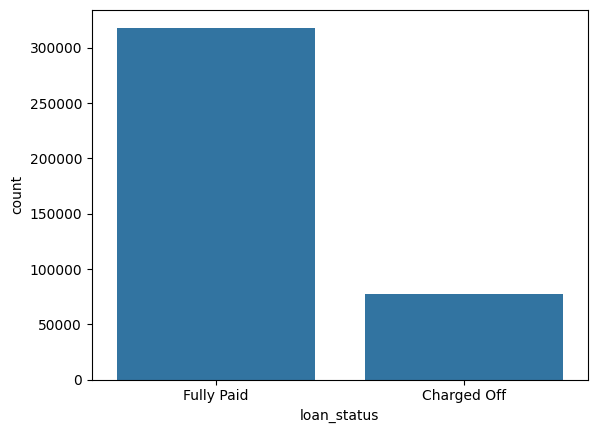

In [7]:
sns.countplot(x='loan_status',data=df)

In [8]:
df["loan_status"].value_counts()

loan_status
Fully Paid     318357
Charged Off     77673
Name: count, dtype: int64

##### First Observation is that the data is imbalanced. Percentage of fully paid is very much high. So we can't train our model with this imbalanced data as it will became a biased model

<Axes: >

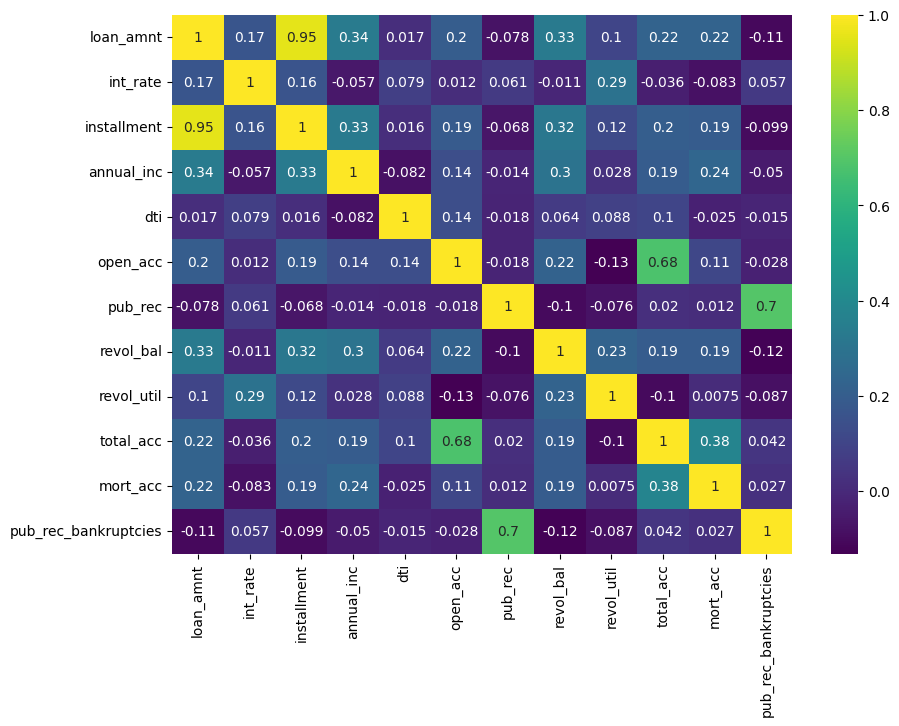

In [9]:
plt.figure(figsize=(10,7))
corr = df.corr(numeric_only=True)
sns.heatmap(corr,annot=True,cmap="viridis")

<Axes: xlabel='loan_amnt', ylabel='Count'>

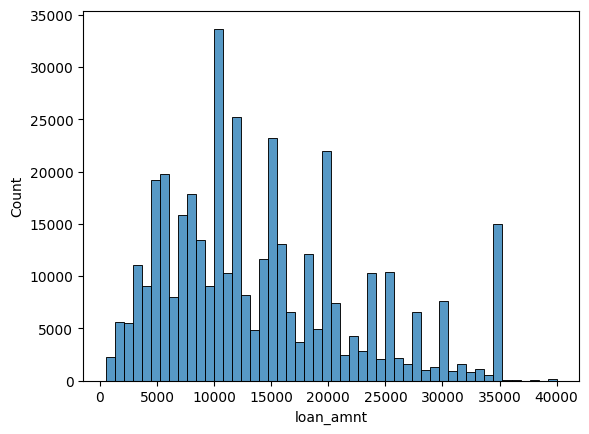

In [10]:
plt.Figure(figsize=(12,7))
sns.histplot(df['loan_amnt'],bins=50)

<Axes: xlabel='installment', ylabel='loan_amnt'>

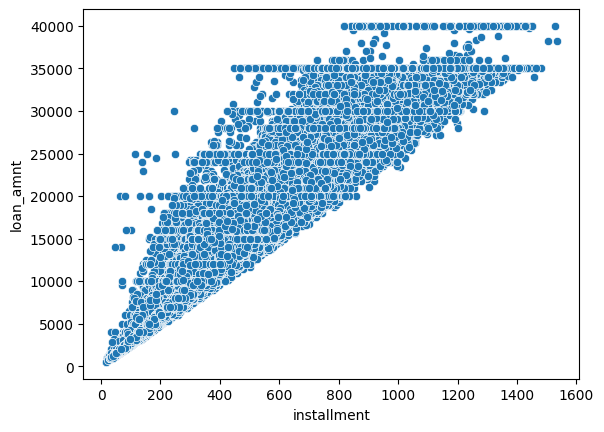

In [11]:
sns.scatterplot(y="loan_amnt",x="installment",data=df)

<Axes: xlabel='open_acc', ylabel='total_acc'>

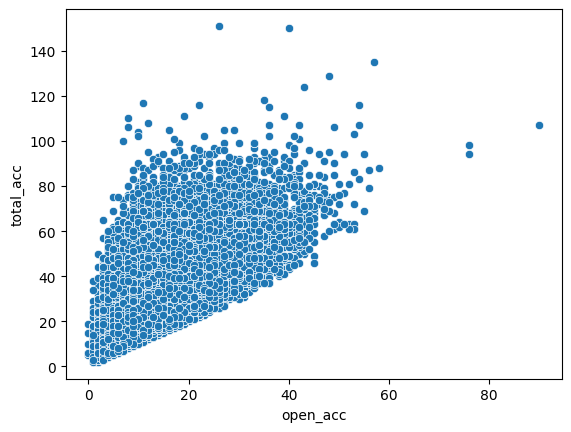

In [18]:
sns.scatterplot(y="total_acc",x="open_acc",data=df)

In [13]:
df["grade"].unique()

array(['B', 'A', 'C', 'E', 'D', 'F', 'G'], dtype=object)

<Axes: xlabel='grade', ylabel='count'>

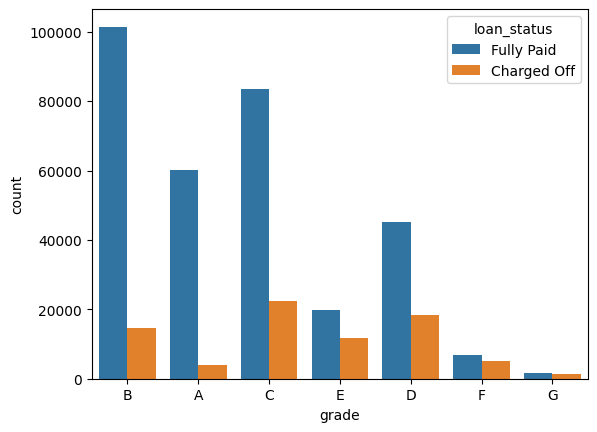

In [14]:
sns.countplot(x="grade",hue="loan_status",data=df)